# Kepler's Second Law

## The law 

Draw a line from the Sun to a moving planet. That line sweeps out a **pie-slice** shape as the planet moves.

**Kepler's second law:** If you wait the **same amount of time** each time, each pie-slice has the **same area**—whether the planet is close to the Sun or far away.

So the slice can look **thin and pointy** (planet close in, moving fast) or **wide and shallow** (planet far out, moving slow). Different *shape*, same *area*.

## Why that happens 

1. **Angular momentum** measures how much "spinning around the Sun" the orbit has. For one planet, it stays **nearly constant** because gravity pulls toward the Sun—it doesn't twist the orbit.

2. In the code we use a standard symbol **h** (really **h** with an arrow in textbooks):

    - **r** is the position vector from the Sun to the planet (where the planet is).
    - **v** is the velocity vector (which way and how fast it moves).
    - **h = r × v** is the cross product. It encodes how much the motion wraps around the Sun. Its size $|h|$ stays constant in this simulation.

3. Geometry link: the **area swept per second** is $|h|/2$. Since $|h|$ is constant, **equal times give equal areas**. That *is* Kepler's second law in Newtonian language.

## What this notebook does

Simulate a planet on an **ellipse**, split one orbit into equal time chunks, color each chunk, and check that the areas match.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np

from src.kepler_second_law import areas_in_equal_time_intervals, theoretical_areal_rate
from src.physics import AU, M_SUN, circular_orbital_speed
from src.simulation import integrate_two_body, measure_orbital_period
from src.visualization import (
    apply_dark_style,
    plot_equal_time_areas,
    plot_kepler_second_law_sectors,
    plot_speed_vs_radius,
)

%matplotlib inline
apply_dark_style()


## 1. Set up an elliptical orbit

We need an **ellipse**, not a circle, so the "thin slice / wide slice" effect is obvious.

**Initial conditions (step by step):**

- **1 AU** = put the planet at Earth's distance from the Sun (about 150 million km). In code it sits on the **+x axis**: `(AU, 0, 0)`.
- **Tangential speed** = velocity pointing straight **along +y** (sideways, not toward or away from the Sun).
- **Circular speed** at 1 AU = the exact speed for a **perfect circle** at that distance: $v_{\mathrm{circ}} = \sqrt{GM/r}$.

We choose speed **0.72 × v_circ**—**slower** than circular. That means:

- The planet does **not** have enough sideways speed to stay on a circle.
- It falls in a bit, swings around the Sun, and comes back out → a **closed ellipse** (stays bound to the Sun).

**Periapsis** = closest approach to the Sun (planet **fastest** there). **Apoapsis** = farthest point (**slowest** there). Kepler's second law is easiest to *see* on an ellipse because speed changes a lot around the orbit.


In [2]:
r0 = AU
v_circ = circular_orbital_speed(r0, M_SUN)
pos0 = np.array([r0, 0.0, 0.0])
vel0 = np.array([0.0, 0.72 * v_circ, 0.0])  # try 0.65–0.95 * v_circ

dt = 1800.0  # 30 min timestep (seconds)
n_steps = int(500 * 86400 / dt)
history = integrate_two_body(pos0, vel0, M_SUN, dt, n_steps)

period = measure_orbital_period(history)
print(f"Estimated orbital period: {period / 86400:.1f} days")


Estimated orbital period: 202.5 days


## 2. Equal-time sectors (visual Kepler II)

Each colored triangle connects the Sun to the planet at the start and end of an equal **time** interval. Near periapsis the arc is long in angle but the radius is short; near apoapsis the opposite — areas balance.


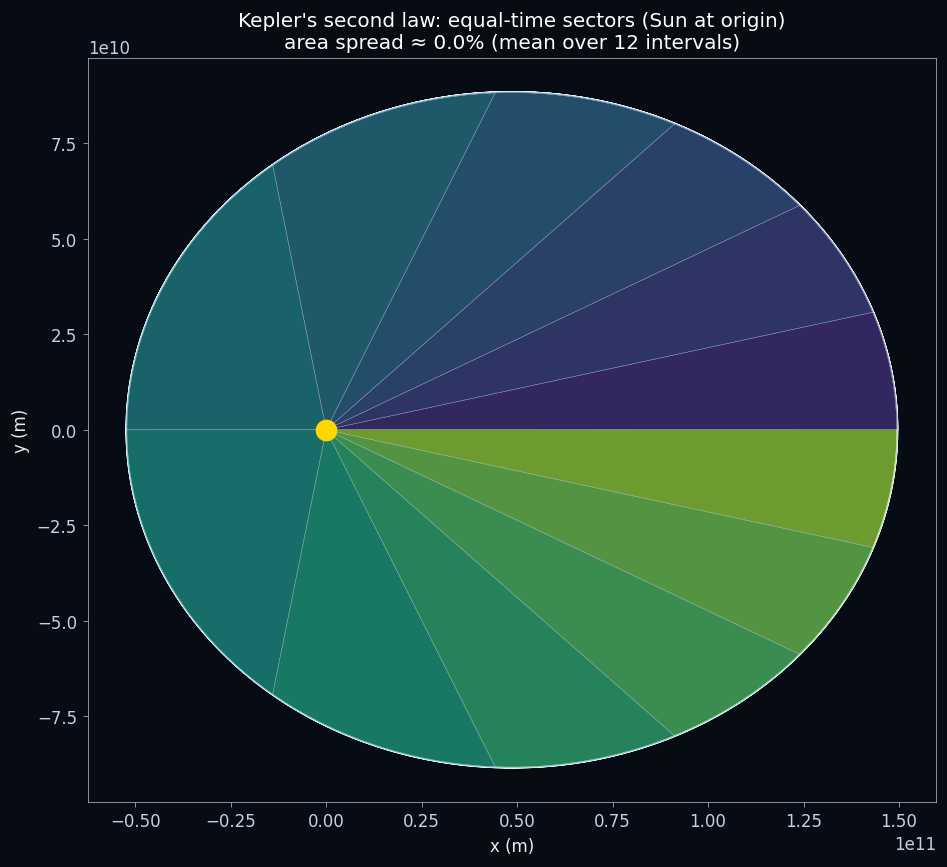

Mean swept area: 2.339e+21 m²
Theory |h|/2 × Δt:  2.339e+21 m²
Relative spread (max-min)/mean: 0.0%


In [3]:
N_SECTORS = 12
t_start = history.times[0]
t_end = t_start + period

areas, idx = areas_in_equal_time_intervals(history, N_SECTORS, t_start, t_end)
areal_rate = theoretical_areal_rate(history)
dt_interval = period / N_SECTORS

fig = plot_kepler_second_law_sectors(history, idx, areas)
plt.show()

print(f"Mean swept area: {areas.mean():.3e} m²")
print(f"Theory |h|/2 × Δt:  {areal_rate * dt_interval:.3e} m²")
print(f"Relative spread (max-min)/mean: {(areas.max()-areas.min())/areas.mean()*100:.1f}%")


## 3. Bar chart: area per interval

If the simulation and sector approximation are good, all bars sit near the dashed line $|\mathbf{h}|/2 \,\Delta t$.


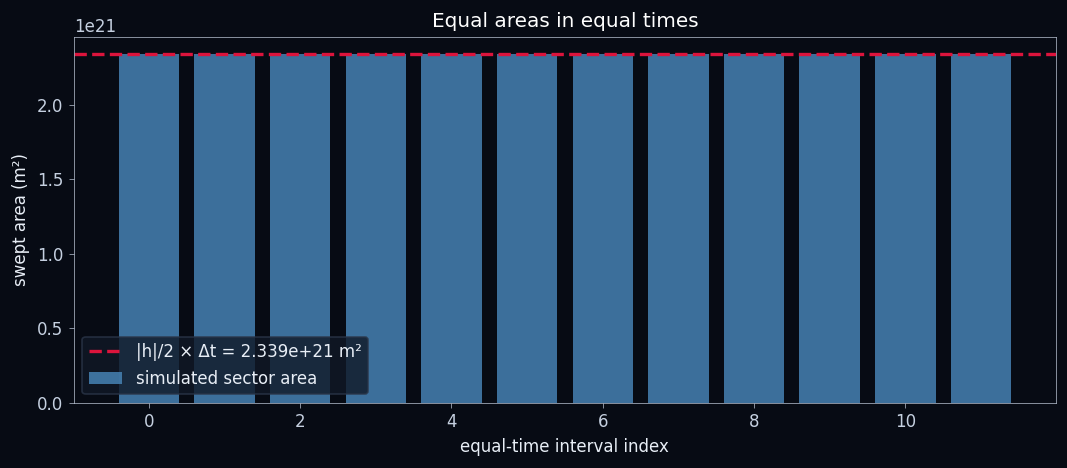

In [4]:
fig = plot_equal_time_areas(areas, areal_rate, dt_interval)
plt.show()


## 4. Why it looks that way: speed vs radius

Kepler II is the geometric face of **angular momentum conservation**: $|\mathbf{v}|$ is larger when $|\mathbf{r}|$ is smaller (for this 2D ellipse).


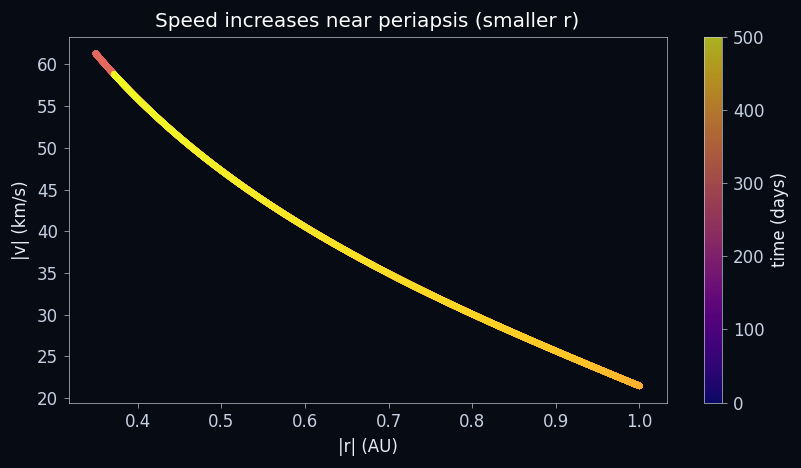

In [5]:
fig = plot_speed_vs_radius(history)
plt.show()


## 5. Experiments to try

1. Change `0.72 * v_circ` → more eccentric orbit; watch sector **shape** change but areas stay similar.
2. Use `1.0 * v_circ` for a circle: sectors look equal in **width** as well as area.
3. Increase `dt` in the integrator until area spread grows — numerical error, not physics.
4. Compare one period vs half a period (`N_SECTORS` and `t_end`).
